## FIELD Preprocessing - v2



**BT Velocity target naming:**
| Variable | Meaning |
| --- | --- |
| `BT_Vel_pre`    | Mean of velocity components (version 1) - ignored | 
| `BT_Vel_stage0` | Unfiltered horizontal magnitude: sqrt(E²+N²) |
| `BT_Vel_stage1` | + direction filter |
| `BT_Vel_stage2` | + direction + error-velocity filter (Steps 1+3) |
| `BT_Vel_stage3` | + direction + magnitude/outlier filter (Steps 1+2) |
| `BT_Vel_stage4` | + direction + magnitude + error-velocity (Steps 1+2+3 ≈ va2) |

**Field main target:** `BT_Vel_stage1` (mobile rQPOD )



In [1]:
from scipy.io import loadmat
import pandas as pd
import numpy as np

BEAM_ANGLE_DEG = 25.0          # RS5 slant beam angle (degrees)
COS_BEAM      = np.cos(np.radians(BEAM_ANGLE_DEG))
ALPHA_ABS     = 0.07           # Acoustic attenuation for Relative_ABS (dB/m)


### Helper: Standard Feature Extractor

Extracts per-ensemble values from matrix fields (averaged over bins/beams)
and scalar fields directly.


In [2]:
def extract_feature(mat_data, struct_name, field_name, is_matrix=True):
    """
    Extract per-ensemble values from a .mat struct field.
    
    Parameters
    ----------
    mat_data    : dict from loadmat
    struct_name : str  e.g. 'WaterTrack', 'Summary', 'System'
    field_name  : str  e.g. 'Vel_StdDev', 'Mean_Speed', 'SNR'
    is_matrix   : bool  True → average over non-time axes; False → use directly
    
    Returns
    -------
    np.ndarray of shape (n_ensembles,)
    """
    try:
        struct = mat_data[struct_name]
        data   = getattr(struct, field_name)
        if is_matrix:
            # Average over all non-time axes (bins, beams)
            # Time axis is always the LAST axis for RS5 .mat files
            if data.ndim == 1:
                return data  # Already per-ensemble
            elif data.ndim == 2:
                return np.nanmean(data, axis=0)  # Mean over bins → (n_ens,)
            elif data.ndim == 3:
                return np.nanmean(data, axis=(0, 1))  # Mean over bins+beams → (n_ens,)
        else:
            return data  # Scalar per ensemble
    except Exception as e:
        print(f'  Warning: {struct_name}.{field_name} failed: {e}')
        return None


### BT Velocity Computation

**previous (ignored):** `mean(max(0, E), max(0, N), max(0, Up), max(0, Diff))`

- `BT_Vel_stage0`    = `sqrt(BT_E² + BT_N²)` 
- `BT_Vel_stage1` = + direction filter =  Step 1 (**Field MAIN TARGET**)
- `BT_Vel_stage2` = + error velocity filter = Steps 1+3
- `BT_Vel_stage3` = + magnitude filter = Steps 1+2
- `BT_Vel_stage4` = + magnitude + error = Steps 1+2+3

In [ ]:
def compute_bt_velocity_corrected(mat_data):
    """
    Compute physically correct BT velocity targets.

    Returns dict with per-ensemble arrays:
      'BT_Vel_pre' : original (wrong) computation — kept for comparison
      'BT_Vel_stage0'          : sqrt(E²+N²), Use_BT mask only
      'BT_Vel_stage1'       : BT_Vel_stage0 + direction filter 
      'BT_Vel_stage2'       : BT_Vel_stage1 + error vel filter  
      'BT_Vel_stage3'       : BT_Vel_stage1 + magnitude filter  
      'BT_Vel_stage4'       : BT_Vel_stage1 + magnitude + error   
      'Error_Velocity'  : |BT_Diff| per ensemble (beam inconsistency feature)
    """
    bt   = mat_data['BottomTrack']
    gen  = mat_data['General']
    summ = mat_data['Summary']

    n       = bt.BT_Vel.shape[0]
    BT_E    = bt.BT_Vel[:, 0]   # East component
    BT_N    = bt.BT_Vel[:, 1]   # North component
    BT_Up   = bt.BT_Vel[:, 2]   # Vertical component
    BT_Diff = bt.BT_Vel[:, 3]   # Difference / error velocity

    UsesBT = gen.Use_BT.astype(bool)  # Valid BT lock flag

    # ── Previous computation — kept only for sensitivity comparison
    bt_copy = bt.BT_Vel.copy()
    bt_copy[bt_copy < 0] = 0
    BT_Vel_pre = np.nanmean(bt_copy, axis=1)

    # ── STEP 0: Horizontal speed magnitude (physically correct)
    va_horiz = np.sqrt(BT_E**2 + BT_N**2)

    # ── STEP 1: Direction filter 
    #    Remove pings where bedload moves >90° from flow direction
    Wv_E = summ.Mean_Vel[:, 0]   # Depth-averaged eastward water velocity
    Wv_N = summ.Mean_Vel[:, 1]   # Depth-averaged northward water velocity

    flow_angle   = np.arctan2(Wv_N, Wv_E)
    bt_angle     = np.arctan2(BT_N, BT_E)
    angle_diff   = np.abs(np.degrees(flow_angle - bt_angle))
    angle_diff   = np.where(angle_diff > 180, 360 - angle_diff, angle_diff)
    direction_ok = angle_diff < 90.0

    # ── STEP 2: Magnitude filter 
    #    Remove pings where apparent bedload speed > depth-averaged water speed
    #    Physical rationale: bedload cannot outrun water
    Water_Speed   = np.sqrt(Wv_E**2 + Wv_N**2)
    magnitude_ok  = va_horiz < Water_Speed

    # ── STEP 3: Error velocity filter (beam inconsistency)
    #    Threshold: mean + 2*std of |BT_Diff| over full transect
    err_thresh = np.nanmean(np.abs(BT_Diff)) + 2.0 * np.nanstd(BT_Diff)
    error_ok   = np.abs(BT_Diff) < err_thresh

    # ── Compose targets
    mask_raw = UsesBT
    mask_s1  = UsesBT & direction_ok                              # Step 1  = va1
    mask_s2  = UsesBT & direction_ok & error_ok                  # Steps 1+3
    mask_s3  = UsesBT & direction_ok & magnitude_ok              # Steps 1+2
    mask_s4  = UsesBT & direction_ok & magnitude_ok & error_ok  # Steps 1+2+3 ≈ va2

    BT_Vel_stage0    = np.where(mask_raw, va_horiz, np.nan)
    BT_Vel_stage1 = np.where(mask_s1,  va_horiz, np.nan)  # va1
    BT_Vel_stage2 = np.where(mask_s2,  va_horiz, np.nan)  # Steps 1+3
    BT_Vel_stage3 = np.where(mask_s3,  va_horiz, np.nan)  # Steps 1+2
    BT_Vel_stage4 = np.where(mask_s4,  va_horiz, np.nan)  # Steps 1+2+3 ≈ va2

    # ── Error velocity as feature (|BT_Diff| per ensemble)
    Error_Velocity = np.abs(BT_Diff)

    # ── Filtering statistics
    pct_s1 = 100 * mask_s1.sum() / n
    pct_s2 = 100 * mask_s2.sum() / n
    pct_s3 = 100 * mask_s3.sum() / n
    pct_s4 = 100 * mask_s4.sum() / n

    return {
        'BT_Vel_pre': BT_Vel_pre,
        'BT_Vel_stage0':          BT_Vel_stage0,
        'BT_Vel_stage1':       BT_Vel_stage1,
        'BT_Vel_stage2':       BT_Vel_stage2,
        'BT_Vel_stage3':       BT_Vel_stage3,
        'BT_Vel_stage4':       BT_Vel_stage4,
        'Error_Velocity':  Error_Velocity,
        '_stats': {
            'n':       n,
            'pct_s1':  pct_s1,
            'pct_s2':  pct_s2,
            'pct_s3':  pct_s3,
            'pct_s4':  pct_s4,
        }
    }

### File Paths

Update paths to match your local directory structure.


In [4]:
from pathlib import Path

# ── Update this path to your local directory ────────────────────────────────
BASE = Path(r'C:\Users\thtuh\Documents\MATLAB\field')

file_paths = {
    # January 2023
    'Transect_01_20230118': BASE / '01-Transect_20230118103246.mat',
    'Transect_02_20230118': BASE / '02-Transect_20230118104553.mat',
    'Transect_03_20230118': BASE / '03-Transect_20230118105035.mat',
    'Transect_04_20230118': BASE / '04-Transect_20230118105343.mat',
    'Transect_05_20230118': BASE / '05-Transect_20230118105633.mat',
    'Transect_06_20230118': BASE / '06-Transect_20230118110009.mat',

    # June 2023
    'Transect_01_20230607': BASE / '01-Transect_20230607123907.mat',
    'Transect_02_20230607': BASE / '02-Transect_20230607125437.mat',
    'Transect_03_20230607': BASE / '03-Transect_20230607125734.mat',
    'Transect_04_20230607': BASE / '04-Transect_20230607130155.mat',
    'Transect_05_20230607': BASE / '05-Transect_20230607130606.mat',

    # August 2023 campaign 1
    'Transect_01_20230808': BASE / '01-Transect_20230808190806.mat',
    'Transect_02_20230808': BASE / '02-Transect_20230808191441.mat',
    'Transect_03_20230808': BASE / '03-Transect_20230808191758.mat',
    'Transect_04_20230808': BASE / '04-Transect_20230808192055.mat',
    'Transect_05_20230808': BASE / '05-Transect_20230808192351.mat',

    # August 2023 campaign 2
    'Transect_01_20230829': BASE / '01-Transect_20230829161300.mat',
    'Transect_02_20230829': BASE / '02-Transect_20230829162347.mat',
    'Transect_03_20230829': BASE / '03-Transect_20230829163132.mat',
    'Transect_04_20230829': BASE / '04-Transect_20230829164057.mat',
    'Transect_05_20230829': BASE / '05-Transect_20230829165037.mat',
    'Transect_06_20230829': BASE / '06-Transect_20230829170426.mat',
    'Transect_07_20230829': BASE / '07-Transect_20230829171342.mat',
    'Transect_08_20230829': BASE / '08-Transect_20230829172530.mat',

    # October 2023
    'Transect_01_20231027': BASE / '01-Transect_20231027121112.mat',
    'Transect_02_20231027': BASE / '02-Transect_20231027122752.mat',
    'Transect_03_20231027': BASE / '03-Transect_20231027123056.mat',
    'Transect_04_20231027': BASE / '04-Transect_20231027123404.mat',
    'Transect_05_20231027': BASE / '05-Transect_20231027123719.mat',
    'Transect_06_20231027': BASE / '06-Transect_20231027124040.mat',
    'Transect_07_20231027': BASE / '07-Transect_20231027124401.mat',
    'Transect_08_20231027': BASE / '08-Transect_20231027124713.mat',

    # December 2023
    'Transect_01_20231211': BASE / '01-Transect_20231211093536.mat',
    'Transect_02_20231211': BASE / '02-Transect_20231211093916.mat',
    'Transect_03_20231211': BASE / '03-Transect_20231211094331.mat',
    'Transect_04_20231211': BASE / '04-Transect_20231211094620.mat',
    'Transect_05_20231211': BASE / '05-Transect_20231211094909.mat',
    'Transect_06_20231211': BASE / '06-Transect_20231211095515.mat',
    'Transect_07_20231211': BASE / '07-Transect_20231211095900.mat',

    # January 2024
    'Transect_01_20240103': BASE / '01-Transect_20240103121207.mat',
    'Transect_02_20240103': BASE / '02-Transect_20240103121450.mat',
    'Transect_03_20240103': BASE / '03-Transect_20240103121651.mat',
    'Transect_04_20240103': BASE / '04-Transect_20240103121856.mat',
    'Transect_05_20240103': BASE / '05-Transect_20240103122100.mat',
    'Transect_06_20240103': BASE / '06-Transect_20240103122302.mat',
    'Transect_07_20240103': BASE / '07-Transect_20240103122612.mat',
}

# Convert Path objects to strings if your loading function needs string paths
file_paths = {key: str(path) for key, path in file_paths.items()}

print(f'Total transects: {len(file_paths)}')



Total transects: 46


### Main Processing Loop

Extracts all features and BT velocity targets for every transect.


In [5]:
all_rows   = []
filt_stats = []   # Filtering retention per transect

for label, path in file_paths.items():
    try:
        mat = loadmat(path, struct_as_record=False, squeeze_me=True)
    except Exception as e:
        print(f'  SKIP {label}: {e}')
        continue

    # ── 1. BT velocity targets (corrected) ───────────────────────────────
    bt_results = compute_bt_velocity_corrected(mat)
    st = bt_results['_stats']
    filt_stats.append({
        'Transect':      label,
        'N_total':       st['n'],
        'pct_va_stage1': round(st['pct_s1'], 1),
        'pct_va_stage2': round(st['pct_s2'], 1),
        'pct_va_stage3': round(st['pct_s3'], 1),
        'pct_va_stage4': round(st['pct_s4'], 1),
    })
    print(f'  {label}: N={st["n"]}  '
          f's1={st["pct_s1"]:.0f}%  '
          f's2={st["pct_s2"]:.0f}%  '
          f's3={st["pct_s3"]:.0f}%  '
          f's4={st["pct_s4"]:.0f}%')

    # ── 2. Water column features ──────────────────────────────────────────
    depth      = extract_feature(mat, 'Summary',    'Depth',               is_matrix=False)
    mean_speed = extract_feature(mat, 'Summary',    'Mean_Speed',          is_matrix=False)
    vel_std    = extract_feature(mat, 'WaterTrack', 'Vel_StdDev',          is_matrix=True)
    corr       = extract_feature(mat, 'WaterTrack', 'Correlation',         is_matrix=True)
    vel_exp    = extract_feature(mat, 'WaterTrack', 'Vel_Expected_StdDev', is_matrix=True)
    snr        = extract_feature(mat, 'System',     'SNR',                 is_matrix=True)

    # ── 3. Instrument/settings features (for Section 3.4) ────────────────
    cell_size  = extract_feature(mat, 'System', 'Cell_Size',  is_matrix=False)
    cell_start = extract_feature(mat, 'System', 'Cell_Start', is_matrix=False)

    # ── 4. Derived features ───────────────────────────────────────────────
    n_ens = bt_results['BT_Vel_stage1'].shape[0]

    if cell_start is not None and cell_size is not None:
        bin_dist = (cell_start + cell_size / 2.0) / COS_BEAM
    else:
        bin_dist = np.full(n_ens, np.nan)

    if snr is not None and bin_dist is not None:
        rel_abs = snr + 20 * np.log10(np.maximum(bin_dist, 0.01)) + 2 * ALPHA_ABS * bin_dist
    else:
        rel_abs = np.full(n_ens, np.nan)

    # ── 5. Build per-ensemble rows ────────────────────────────────────────
    arrays = {
        # BT velocity targets
        'BT_Vel_pre': bt_results['BT_Vel_pre'],
        'BT_Vel_stage0':          bt_results['BT_Vel_stage0'],
        'BT_Vel_stage1':       bt_results['BT_Vel_stage1'],
        'BT_Vel_stage2':       bt_results['BT_Vel_stage2'],
        'BT_Vel_stage3':       bt_results['BT_Vel_stage3'],
        'BT_Vel_stage4':       bt_results['BT_Vel_stage4'],
        # Physical features
        'Depth':           depth,
        'Mean_Speed':      mean_speed,
        'Vel_StdDev':      vel_std,
        'Correlation':     corr,
        'Vel_Expected_StdDev': vel_exp,
        'SNR':             snr,
        # Instrument features
        'Bin_Distance':    bin_dist,
        'Error_Velocity':  bt_results['Error_Velocity'],
        'Cell_Size':       cell_size,
        'Cell_Start':      cell_start,
        # Quality control
        'Relative_ABS':    rel_abs,
    }

    for i in range(n_ens):
        row = {'Transect': label, 'ensemble_idx': i}
        for col, arr in arrays.items():
            if arr is not None and len(arr) > i:
                row[col] = float(arr[i])
            else:
                row[col] = np.nan
        all_rows.append(row)

print(f'\nTotal ensembles: {len(all_rows)}')
df_filt_stats = pd.DataFrame(filt_stats)
print('\nFiltering retention summary:')
print(df_filt_stats.to_string(index=False))


  Transect_01_20230118: N=161  s1=71%  s2=69%  s3=61%  s4=60%
  Transect_02_20230118: N=172  s1=28%  s2=27%  s3=17%  s4=16%
  Transect_03_20230118: N=146  s1=71%  s2=68%  s3=62%  s4=59%
  Transect_04_20230118: N=158  s1=29%  s2=28%  s3=26%  s4=25%
  Transect_05_20230118: N=153  s1=67%  s2=66%  s3=63%  s4=61%
  Transect_06_20230118: N=176  s1=27%  s2=26%  s3=25%  s4=24%
  Transect_01_20230607: N=224  s1=59%  s2=58%  s3=4%  s4=4%
  Transect_02_20230607: N=163  s1=44%  s2=43%  s3=1%  s4=1%
  Transect_03_20230607: N=244  s1=59%  s2=57%  s3=4%  s4=4%

C:\Users\thtuh\AppData\Local\Temp\ipykernel_74008\2420029321.py:27: RuntimeWarning: Mean of empty slice
  return np.nanmean(data, axis=(0, 1))  # Mean over bins+beams → (n_ens,)



  Transect_04_20230607: N=237  s1=56%  s2=54%  s3=6%  s4=6%
  Transect_05_20230607: N=242  s1=62%  s2=62%  s3=4%  s4=4%
  Transect_01_20230808: N=36  s1=69%  s2=67%  s3=64%  s4=61%
  Transect_02_20230808: N=165  s1=70%  s2=66%  s3=68%  s4=65%
  Transect_03_20230808: N=167  s1=40%  s2=38%  s3=40%  s4=38%
  Transect_04_20230808: N=166  s1=67%  s2=64%  s3=66%  s4=63%
  Transect_05_20230808: N=226  s1=38%  s2=37%  s3=38%  s4=37%
  Transect_01_20230829: N=373  s1=57%  s2=53%  s3=13%  s4=12%
  Transect_02_20230829: N=449  s1=34%  s2=33%  s3=9%  s4=9%
  Transect_03_20230829: N=555  s1=52%  s2=51%  s3=20%  s4=19%
  Transect_04_20230829: N=571  s1=49%  s2=47%  s3=3%  s4=3%
  Transect_05_20230829: N=819  s1=45%  s2=44%  s3=23%  s4=22%
  Transect_06_20230829: N=548  s1=38%  s2=36%  s3=7%  s4=7%
  Transect_07_20230829: N=694  s1=53%  s2=51%  s3=23%  s4=23%
  Transect_08_20230829: N=754  s1=35%  s2=34%  s3=12%  s4=12%
  Transect_01_20231027: N=184  s1=62%  s2=62%  s3=62%  s4=62%
  Transect_02_2023

In [ ]:
df = pd.DataFrame(all_rows)

# ── Column order ──────────────────────────────────────────────────────────────
col_order = [
    'Transect', 'ensemble_idx',
    # BT velocity targets (all stages for sensitivity analysis)
    'BT_Vel_pre',   # Original wrong computation — for comparison only
    'BT_Vel_stage0',            # Horizontal magnitude, no filter
    'BT_Vel_stage1',         # + direction filter              = Step 1 (va1)
    'BT_Vel_stage2',         # + error velocity filter         = Steps 1+3
    'BT_Vel_stage3',         # + magnitude filter              = Steps 1+2
    'BT_Vel_stage4',         # + magnitude + error vel filter  = Steps 1+2+3 (≈va2)
    # 7 core features (same as original paper)
    'Depth', 'Mean_Speed', 'Vel_StdDev', 'Correlation',
    'Vel_Expected_StdDev', 'SNR', 'Bin_Distance',
    # New features for Section 3.4 feature set analysis
    'Error_Velocity', 'Cell_Size', 'Cell_Start',
    # Quality control (water-column proxy — NOT riverbed BS)
    'Relative_ABS',
]
df = df[[c for c in col_order if c in df.columns]]

df_clean = df.dropna(subset=['Depth', 'Mean_Speed'])

print(f'Total rows:        {len(df)}')
print(f'After basic clean: {len(df_clean)}')
print(f'\nFiltering retention:')
for col in ['BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2', 'BT_Vel_stage3', 'BT_Vel_stage4']:
    n_v = df_clean[col].notna().sum()
    print(f'  {col:12s}: {n_v:5d} ({100*n_v/len(df_clean):.1f}%)')
print(f'\nColumn list:')
print(df_clean.columns.tolist())
print(f'\nSample:')
print(df_clean.head(3))


Total rows:        10869
After basic clean: 10869

Filtering retention:
  BT_Vel_stage0: 10869 (100.0%)
  BT_Vel_stage1:  5297 (48.7%)
  BT_Vel_stage2:  5130 (47.2%)
  BT_Vel_stage3:  3072 (28.3%)
  BT_Vel_stage4:  2988 (27.5%)

Column list:
['Transect', 'ensemble_idx', 'BT_Vel_pre', 'BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2', 'BT_Vel_stage3', 'BT_Vel_stage4', 'Depth', 'Mean_Speed', 'Vel_StdDev', 'Correlation', 'Vel_Expected_StdDev', 'SNR', 'Bin_Distance', 'Error_Velocity', 'Cell_Size', 'Cell_Start', 'Relative_ABS']

Sample:
               Transect  ensemble_idx  BT_Vel_pre  BT_Vel_stage0  \
0  Transect_01_20230118             0    0.002594       0.030901   
1  Transect_01_20230118             1    0.000000       0.022516   
2  Transect_01_20230118             2    0.002833       0.014663   

   BT_Vel_stage1  BT_Vel_stage2  BT_Vel_stage3  BT_Vel_stage4     Depth  \
0       0.030901       0.030901       0.030901       0.030901  0.630651   
1       0.022516       0.022516       0

In [7]:
# ── Update output path ────────────────────────────────────────────────────────
OUTPUT = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_Corrected_v2.xlsx'

df_clean.to_excel(OUTPUT, index=False)
print(f'Saved: {OUTPUT}')
print(f'Shape: {df_clean.shape}')

# Also save filtering stats
STATS_OUT = OUTPUT.replace('.xlsx', '_filtering_stats.xlsx')
df_filt_stats.to_excel(STATS_OUT, index=False)
print(f'Filtering stats saved: {STATS_OUT}')


Saved: C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_Corrected_v2.xlsx
Shape: (10869, 19)
Filtering stats saved: C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_Corrected_v2_filtering_stats.xlsx


### Correlation Heatmap — Updated on BT_Vel_stage1


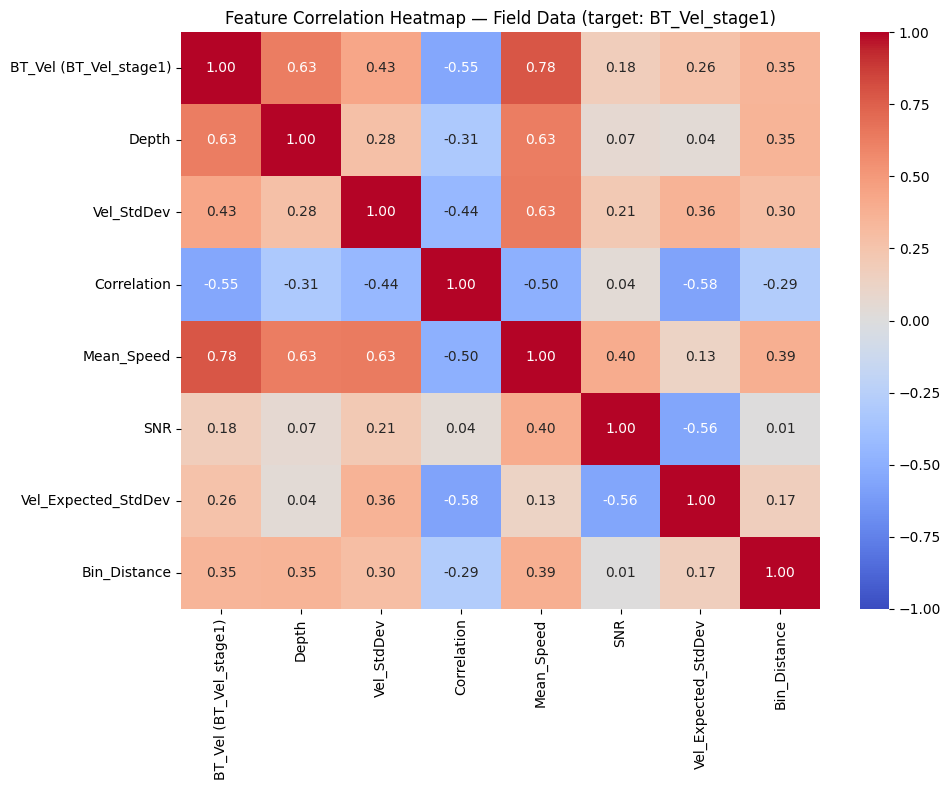

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use BT_Vel_stage1 as the target in correlation heatmap
heatmap_features = [
    'BT_Vel_stage1', 'Depth', 'Vel_StdDev', 'Correlation',
    'Mean_Speed', 'SNR', 'Vel_Expected_StdDev', 'Bin_Distance'
]

df_heat = df_clean[heatmap_features].rename(columns={'BT_Vel_stage1': 'BT_Vel (BT_Vel_stage1)'})
df_heat = df_heat.dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_heat.corr(), annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, cbar=True
)
plt.title('Feature Correlation Heatmap — Field Data (target: BT_Vel_stage1)')
plt.tight_layout()
plt.savefig('field_correlation_heatmap_va_stage1.png', dpi=150)
plt.show()


In [9]:
# Descriptive statistics for paper Table / Section 2.2
stat_features = [
    'BT_Vel_stage1', 'Depth', 'Vel_StdDev', 'Correlation',
    'Mean_Speed', 'SNR', 'Vel_Expected_StdDev', 'Bin_Distance',
    'Error_Velocity', 'Cell_Size', 'Cell_Start'
]

stats = df_clean[stat_features].describe().T[['mean', 'std', 'min', 'max']].round(5)
stats['range'] = stats['min'].astype(str) + ' → ' + stats['max'].astype(str)

print('\n========= FIELD DATASET STATISTICS (BT_Vel_stage1) =========')
print(stats.to_string())

# Filtering summary
print('\n========= FILTERING RETENTION =========')
for col in ['BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2', 'BT_Vel_stage3', 'BT_Vel_stage4']:
    n_v = df_clean[col].notna().sum()
    print(f'  {col:12s}: {n_v:5d} ({100*n_v/len(df_clean):.1f}%)')



========= FIELD DATASET STATISTICS (BT_Vel_stage1) =========
                         mean       std      min       max              range
BT_Vel_stage1         0.10984   0.10695  0.00000   0.67220       0.0 → 0.6722
Depth                 1.46331   0.39595  0.00000   3.03077      0.0 → 3.03077
Vel_StdDev            0.00619   0.00931  0.00000   0.07430       0.0 → 0.0743
Correlation          64.37866  15.38084  9.12500  81.64286   9.125 → 81.64286
Mean_Speed            0.17488   0.20933  0.00000   1.21470       0.0 → 1.2147
SNR                  23.43145   7.06901  5.66470  56.70000      5.6647 → 56.7
Vel_Expected_StdDev   0.00769   0.00887  0.00061   0.06844  0.00061 → 0.06844
Bin_Distance          0.18008   0.03107  0.11918   0.62473  0.11918 → 0.62473
Error_Velocity        0.00264   0.00745  0.00000   0.25545      0.0 → 0.25545
Cell_Size             0.07020   0.02776  0.01200   0.30000        0.012 → 0.3
Cell_Start            0.12811   0.02079  0.10201   0.42511  0.10201 → 0.42511

=

---
## Backscatter Strength (BS_rel) from RS5 Raw `.rsqmb` Files

**Why not from `.mat`?**
The standard RS5 MATLAB export does not include `Bt.Strength` (BT echo intensity).
This field exists only in the raw `.rsqmb` format (ZIP archive → `RawData.jsonlog`).

```
BS_rel [dB] = Bt.Strength + 20·log10(R_BT) + 2·α·R_BT
```

where:
- `Bt.Strength` = BT echo intensity per beam, mean over 4 beams [dB]
- `R_BT` = `Bt.Range` = slant range to bed per beam, mean over 4 beams [m]
- `α` = freshwater absorption at 3 MHz, T-dependent [dB/m]
- `SL0` (source level) is **unknown** for RS5 → values are **relative**

**Additional outputs:**
- `Bt_Contrast` = Bt.Contrast [dB] — BT echo peak above noise floor
  (physically meaningful: drops as bedload layer thickens)
- `VB_Strength` = Vb.Strength [dB] — vertical beam echo intensity


In [10]:
import zipfile
import json as json_lib

def alpha_freshwater(T_C, f_MHz=3.0):
    """
    Freshwater absorption coefficient [dB/m]
    Empirical formula for SonTek ADCPs (Topping 2007, Shields 2010)
    Validated for 3 MHz, 0–25°C
    """
    return 0.0245 * np.exp(-0.0214 * T_C) * f_MHz**1.6

def safe_mean(lst):
    """Mean of list ignoring None values."""
    vals = [x for x in (lst or []) if x is not None]
    return float(np.mean(vals)) if vals else np.nan


### rsqmb File Mapping

Each `.rsqmb` file contains multiple transects.
Map each transect directory to the corresponding transect label from the `.mat` processing.



In [11]:
# ── Update these paths to your local rsqmb files ──────────────────────────────
RSQMB_BASE = r'C:\Users\thtuh\Documents\MATLAB\field\rsqmb'

RSQMB_MAP = {
    # ── January 2023 ────────────────────────────────────────────────────────
    'Jan2023': {
        'file': rf'{RSQMB_BASE}\Stever_20230118_110403_edited.rsqmb',
        'transects': {
            'AdcpData/01_20230118-093246_Transect_20230118103246/RawData.jsonlog': 'Transect_01_20230118',
            'AdcpData/02_20230118-094553_Transect_20230118104553/RawData.jsonlog': 'Transect_02_20230118',
            'AdcpData/03_20230118-095035_Transect_20230118105035/RawData.jsonlog': 'Transect_03_20230118',
            'AdcpData/04_20230118-095343_Transect_20230118105343/RawData.jsonlog': 'Transect_04_20230118',
            'AdcpData/05_20230118-095633_Transect_20230118105633/RawData.jsonlog': 'Transect_05_20230118',
            'AdcpData/06_20230118-100009_Transect_20230118110009/RawData.jsonlog': 'Transect_06_20230118',
        }
    },

    # ── June 2023 ───────────────────────────────────────────────────────────
    'Jun2023': {
        'file': rf'{RSQMB_BASE}\Stever_20230607_131056_edited.rsqmb',
        'transects': {
            'AdcpData/01_20230607-103907_Transect_20230607123907/RawData.jsonlog': 'Transect_01_20230607',
            'AdcpData/02_20230607-105437_Transect_20230607125437/RawData.jsonlog': 'Transect_02_20230607',
            'AdcpData/03_20230607-105734_Transect_20230607125734/RawData.jsonlog': 'Transect_03_20230607',
            'AdcpData/04_20230607-110155_Transect_20230607130155/RawData.jsonlog': 'Transect_04_20230607',
            'AdcpData/05_20230607-110606_Transect_20230607130606/RawData.jsonlog': 'Transect_05_20230607',
        }
    },

    # ── August 2023 campaign 1 ─────────────────────────────────────────────
    'Aug2023_20230808': {
        'file': rf'{RSQMB_BASE}\Stever_20230808_192834_edited.rsqmb',
        'transects': {
            'AdcpData/01_20230808-170806_Transect_20230808190806/RawData.jsonlog': 'Transect_01_20230808',
            'AdcpData/02_20230808-171441_Transect_20230808191441/RawData.jsonlog': 'Transect_02_20230808',
            'AdcpData/03_20230808-171758_Transect_20230808191758/RawData.jsonlog': 'Transect_03_20230808',
            'AdcpData/04_20230808-172055_Transect_20230808192055/RawData.jsonlog': 'Transect_04_20230808',
            'AdcpData/05_20230808-172351_Transect_20230808192351/RawData.jsonlog': 'Transect_05_20230808',
        }
    },

    # ── August 2023 campaign 2 ─────────────────────────────────────────────
    'Aug2023_20230829': {
        'file': rf'{RSQMB_BASE}\Stever_20230829_173858_edited.rsqmb',
        'transects': {
            'AdcpData/01_20230829-141300_Transect_20230829161300/RawData.jsonlog': 'Transect_01_20230829',
            'AdcpData/02_20230829-142347_Transect_20230829162347/RawData.jsonlog': 'Transect_02_20230829',
            'AdcpData/03_20230829-143132_Transect_20230829163132/RawData.jsonlog': 'Transect_03_20230829',
            'AdcpData/04_20230829-144057_Transect_20230829164057/RawData.jsonlog': 'Transect_04_20230829',
            'AdcpData/05_20230829-145037_Transect_20230829165037/RawData.jsonlog': 'Transect_05_20230829',
            'AdcpData/06_20230829-150426_Transect_20230829170426/RawData.jsonlog': 'Transect_06_20230829',
            'AdcpData/07_20230829-151342_Transect_20230829171342/RawData.jsonlog': 'Transect_07_20230829',
            'AdcpData/08_20230829-152530_Transect_20230829172530/RawData.jsonlog': 'Transect_08_20230829',
        }
    },

    # ── October 2023 ───────────────────────────────────────────────────────
    'Oct2023': {
        'file': rf'{RSQMB_BASE}\Stever_20231027_125535_edited.rsqmb',
        'transects': {
            'AdcpData/01_20231027-101112_Transect_20231027121112/RawData.jsonlog': 'Transect_01_20231027',
            'AdcpData/02_20231027-102752_Transect_20231027122752/RawData.jsonlog': 'Transect_02_20231027',
            'AdcpData/03_20231027-103056_Transect_20231027123056/RawData.jsonlog': 'Transect_03_20231027',
            'AdcpData/04_20231027-103404_Transect_20231027123404/RawData.jsonlog': 'Transect_04_20231027',
            'AdcpData/05_20231027-103719_Transect_20231027123719/RawData.jsonlog': 'Transect_05_20231027',
            'AdcpData/06_20231027-104040_Transect_20231027124040/RawData.jsonlog': 'Transect_06_20231027',
            'AdcpData/07_20231027-104401_Transect_20231027124401/RawData.jsonlog': 'Transect_07_20231027',
            'AdcpData/08_20231027-104713_Transect_20231027124713/RawData.jsonlog': 'Transect_08_20231027',
        }
    },

    # ── December 2023 ──────────────────────────────────────────────────────
    'Dec2023': {
        'file': rf'{RSQMB_BASE}\Stever_20231211_100355_edited.rsqmb',
        'transects': {
            'AdcpData/01_20231211-083536_Transect_20231211093536/RawData.jsonlog': 'Transect_01_20231211',
            'AdcpData/02_20231211-083916_Transect_20231211093916/RawData.jsonlog': 'Transect_02_20231211',
            'AdcpData/03_20231211-084331_Transect_20231211094331/RawData.jsonlog': 'Transect_03_20231211',
            'AdcpData/04_20231211-084620_Transect_20231211094620/RawData.jsonlog': 'Transect_04_20231211',
            'AdcpData/05_20231211-084909_Transect_20231211094909/RawData.jsonlog': 'Transect_05_20231211',
            'AdcpData/06_20231211-085515_Transect_20231211095515/RawData.jsonlog': 'Transect_06_20231211',
            'AdcpData/07_20231211-085900_Transect_20231211095900/RawData.jsonlog': 'Transect_07_20231211',
        }
    },

    # ── January 2024 ───────────────────────────────────────────────────────
    'Jan2024': {
        'file': rf'{RSQMB_BASE}\Stever_20240103_123038_edited.rsqmb',
        'transects': {
            'AdcpData/01_20240103-111207_Transect_20240103121207/RawData.jsonlog': 'Transect_01_20240103',
            'AdcpData/02_20240103-111450_Transect_20240103121450/RawData.jsonlog': 'Transect_02_20240103',
            'AdcpData/03_20240103-111651_Transect_20240103121651/RawData.jsonlog': 'Transect_03_20240103',
            'AdcpData/04_20240103-111856_Transect_20240103121856/RawData.jsonlog': 'Transect_04_20240103',
            'AdcpData/05_20240103-112100_Transect_20240103122100/RawData.jsonlog': 'Transect_05_20240103',
            'AdcpData/06_20240103-112302_Transect_20240103122302/RawData.jsonlog': 'Transect_06_20240103',
            'AdcpData/07_20240103-112612_Transect_20240103122612/RawData.jsonlog': 'Transect_07_20240103',
        }
    },
}

print('rsqmb mapping defined.')
print(f'RSQMB directory: {RSQMB_BASE}')
print(f'Campaigns: {list(RSQMB_MAP.keys())}')

total_t = sum(len(v["transects"]) for v in RSQMB_MAP.values())
print(f'Total transects mapped: {total_t}')

rsqmb mapping defined.
RSQMB directory: C:\Users\thtuh\Documents\MATLAB\field\rsqmb
Campaigns: ['Jan2023', 'Jun2023', 'Aug2023_20230808', 'Aug2023_20230829', 'Oct2023', 'Dec2023', 'Jan2024']
Total transects mapped: 46


** The directory names inside each `.rsqmb` may differ slightly.
Run the cell below first to list exact directory names, then update `RSQMB_MAP` if needed **


In [ ]:
#  Run this to verify exact directory names inside each rsqmb 
print('Verifying rsqmb directory names...\n')
for camp_label, info in RSQMB_MAP.items():
    fpath = info['file']
    print(f'Campaign: {camp_label}')
    try:
        with zipfile.ZipFile(fpath) as z:
            jlogs = sorted([n for n in z.namelist() if n.endswith('RawData.jsonlog')])
            for jl in jlogs:
                print(f'  FOUND:  {jl}')
        # Check what we mapped
        for mapped_jl, mat_label in info['transects'].items():
            status = '✅' if mapped_jl in [n for n in zipfile.ZipFile(fpath).namelist() 
                                           if n.endswith('RawData.jsonlog')] else '❌ CHECK PATH'
            print(f'  MAPPED: {mapped_jl} → {mat_label}  {status}')
    except Exception as e:
        print(f'  ERROR: {e}')
    print()


Verifying rsqmb directory names...

Campaign: Jan2023
  FOUND:  AdcpData/01_20230118-093246_Transect_20230118103246/RawData.jsonlog
  FOUND:  AdcpData/02_20230118-094553_Transect_20230118104553/RawData.jsonlog
  FOUND:  AdcpData/03_20230118-095035_Transect_20230118105035/RawData.jsonlog
  FOUND:  AdcpData/04_20230118-095343_Transect_20230118105343/RawData.jsonlog
  FOUND:  AdcpData/05_20230118-095633_Transect_20230118105633/RawData.jsonlog
  FOUND:  AdcpData/06_20230118-100009_Transect_20230118110009/RawData.jsonlog
  MAPPED: AdcpData/01_20230118-093246_Transect_20230118103246/RawData.jsonlog → Transect_01_20230118  ✅
  MAPPED: AdcpData/02_20230118-094553_Transect_20230118104553/RawData.jsonlog → Transect_02_20230118  ✅
  MAPPED: AdcpData/03_20230118-095035_Transect_20230118105035/RawData.jsonlog → Transect_03_20230118  ✅
  MAPPED: AdcpData/04_20230118-095343_Transect_20230118105343/RawData.jsonlog → Transect_04_20230118  ✅
  MAPPED: AdcpData/05_20230118-095633_Transect_20230118105633/

### BS_rel Extraction Function


In [20]:
def extract_bs_from_rsqmb(rsqmb_path, jsonlog_path_inside_zip):
    """
    Extract Bt.Strength and compute BS_rel from one transect
    inside a .rsqmb file.

    Parameters
    ----------
    rsqmb_path            : str  path to .rsqmb file
    jsonlog_path_inside_zip : str  path to RawData.jsonlog within the ZIP

    Returns
    -------
    pd.DataFrame with columns:
        ensemble_idx, EI_mean, R_BT_mean, Bt_Contrast,
        VB_Strength, Temperature, alpha, TL_2way, BS_rel
    """
    rows = []
    with zipfile.ZipFile(rsqmb_path) as z:
        with z.open(jsonlog_path_inside_zip) as f:
            content = f.read().decode('utf-8-sig')
            for line in content.splitlines():
                parts = line.strip().split(',', 3)
                if len(parts) < 4 or parts[0] != 'RiverSample':
                    continue
                s  = json_lib.loads(parts[3])
                bt = s.get('Bt', {})

                EI_mean     = safe_mean(bt.get('Strength (dB)'))
                R_BT_mean   = safe_mean([x for x in (bt.get('Range (m)') or [])
                                         if x is not None and x > 0.01])
                Bt_Contrast = safe_mean(bt.get('Contrast (dB)'))
                VB_Strength = s.get('Vb', {}).get('Strength (dB)', np.nan)
                T           = s.get('Sensors', {}).get('Temperature (C)', np.nan)

                rows.append({
                    'ensemble_idx': len(rows),
                    'EI_mean':      EI_mean,
                    'R_BT_mean':    R_BT_mean,
                    'Bt_Contrast':  Bt_Contrast,
                    'VB_Strength':  VB_Strength,
                    'Temperature_rsqmb': T,
                })

    df_bs = pd.DataFrame(rows)
    if df_bs.empty:
        return df_bs

    # Compute alpha and TL per ensemble
    df_bs['alpha']   = df_bs['Temperature_rsqmb'].apply(
        lambda t: alpha_freshwater(t) if pd.notna(t) else np.nan)
    df_bs['TL_corr'] = (20.0 * np.log10(np.maximum(df_bs['R_BT_mean'], 0.01))
                        + 2.0 * df_bs['alpha'] * df_bs['R_BT_mean'])
    df_bs['BS_rel']  = df_bs['EI_mean'] + df_bs['TL_corr']

    return df_bs


### Extract BS_rel for All Transects


In [21]:
bs_all = []   # List of DataFrames, one per transect

print('Extracting Bt.Strength from .rsqmb files...\n')
print(f'{"Transect":<25} {"N":>5} {"EI_mean":>8} {"R_BT":>7} '
      f'{"BS_rel":>8} {"Contrast":>9} {"T°C":>5}')
print('-' * 70)

for camp_label, info in RSQMB_MAP.items():
    for jl_path, mat_label in info['transects'].items():
        try:
            df_bs = extract_bs_from_rsqmb(info['file'], jl_path)
            if df_bs.empty:
                print(f'  {mat_label:<23}: EMPTY')
                continue
            df_bs.insert(0, 'Transect', mat_label)
            bs_all.append(df_bs)
            print(f'  {mat_label:<23} '
                  f'{len(df_bs):>5} '
                  f'{df_bs["EI_mean"].mean():>8.1f} '
                  f'{df_bs["R_BT_mean"].mean():>7.3f} '
                  f'{df_bs["BS_rel"].mean():>8.1f} '
                  f'{df_bs["Bt_Contrast"].mean():>9.1f} '
                  f'{df_bs["Temperature_rsqmb"].mean():>5.1f}°C')
        except Exception as e:
            print(f'  {mat_label:<23}: ERROR — {e}')

if bs_all:
    df_bs_all = pd.concat(bs_all, ignore_index=True)
    print(f'\nTotal BS ensembles: {len(df_bs_all)}')
    print(f'BS_rel valid:       {df_bs_all["BS_rel"].notna().sum()} '
          f'({100*df_bs_all["BS_rel"].notna().mean():.0f}%)')
else:
    print('\nNO DATA EXTRACTED — check rsqmb paths and directory names')
    df_bs_all = pd.DataFrame()


Extracting Bt.Strength from .rsqmb files...

Transect                      N  EI_mean    R_BT   BS_rel  Contrast   T°C
----------------------------------------------------------------------
  Transect_01_20230118      161     47.8   1.252     49.2      28.4   6.6°C
  Transect_02_20230118      172     43.3   1.040     42.7      26.2   6.3°C
  Transect_03_20230118      146     49.5   1.355     51.8      28.9   6.1°C
  Transect_04_20230118      158     48.3   1.276     49.9      28.6   6.0°C
  Transect_05_20230118      153     46.8   1.271     48.4      28.5   6.0°C
  Transect_06_20230118      176     47.0   1.276     48.7      27.8   5.9°C
  Transect_01_20230607      224     34.6   1.236     36.1      38.9  19.4°C
  Transect_02_20230607      163     35.0   1.234     36.7      39.1  19.5°C
  Transect_03_20230607      244     34.7   1.209     36.0      39.0  19.6°C
  Transect_04_20230607      237     32.2   1.141     32.6      37.2  19.6°C
  Transect_05_20230607      242     33.7   1.220  

### Merge BS_rel into Main DataFrame and Save Final Output


In [22]:
if not df_bs_all.empty:
    # Merge on Transect + ensemble_idx
    bs_cols = ['Transect', 'ensemble_idx',
               'EI_mean', 'R_BT_mean', 'Bt_Contrast',
               'VB_Strength', 'BS_rel']
    df_final = pd.merge(
        df_clean,
        df_bs_all[bs_cols],
        on=['Transect', 'ensemble_idx'],
        how='left'   # Keep all .mat rows; NaN where no .rsqmb match
    )
    print(f'Merged shape:    {df_final.shape}')
    print(f'BS_rel coverage: {df_final["BS_rel"].notna().sum()} '
          f'({100*df_final["BS_rel"].notna().mean():.0f}%)')
else:
    print('Warning: BS data empty — saving without BS columns')
    df_final = df_clean.copy()

# ── Final column order ─────────────────────────────────────────────────────────
final_col_order = [
    'Transect', 'ensemble_idx',
    # BT targets (all stages)
    'BT_Vel_pre', 'BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2',
    'BT_Vel_stage3',
    'BT_Vel_stage4',
    # 7 core features
    'Depth', 'Mean_Speed', 'Vel_StdDev', 'Correlation',
    'Vel_Expected_StdDev', 'SNR', 'Bin_Distance',
    # Section 3.4 new features
    'Error_Velocity', 'Cell_Size', 'Cell_Start',
    # Section 3.5 BS features
    'BS_rel', 'EI_mean', 'Bt_Contrast', 'VB_Strength', 'R_BT_mean',
    # Quality control
    'Relative_ABS',
]
df_final = df_final[[c for c in final_col_order if c in df_final.columns]]

print(f'\nFinal columns ({len(df_final.columns)}):')
print(df_final.columns.tolist())
print(f'\nSample:')
print(df_final.head(3))


Merged shape:    (10869, 24)
BS_rel coverage: 10795 (99%)

Final columns (24):
['Transect', 'ensemble_idx', 'BT_Vel_pre', 'BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2', 'BT_Vel_stage3', 'BT_Vel_stage4', 'Depth', 'Mean_Speed', 'Vel_StdDev', 'Correlation', 'Vel_Expected_StdDev', 'SNR', 'Bin_Distance', 'Error_Velocity', 'Cell_Size', 'Cell_Start', 'BS_rel', 'EI_mean', 'Bt_Contrast', 'VB_Strength', 'R_BT_mean', 'Relative_ABS']

Sample:
               Transect  ensemble_idx  BT_Vel_pre  BT_Vel_stage0  \
0  Transect_01_20230118             0    0.002594       0.030901   
1  Transect_01_20230118             1    0.000000       0.022516   
2  Transect_01_20230118             2    0.002833       0.014663   

   BT_Vel_stage1  BT_Vel_stage2  BT_Vel_stage3  BT_Vel_stage4     Depth  \
0       0.030901       0.030901       0.030901       0.030901  0.630651   
1       0.022516       0.022516       0.022516       0.022516  0.625413   
2       0.014663       0.014663       0.014663       0.014663  

In [23]:
# ── Save final combined dataset ───────────────────────────────────────────────
FINAL_OUTPUT = (
    r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx'
)

df_final.to_excel(FINAL_OUTPUT, index=False)
print(f'Saved: {FINAL_OUTPUT}')
print(f'Shape: {df_final.shape}')
print(f'\n--- Column summary ---')
for col in df_final.columns:
    n_valid = df_final[col].notna().sum()
    pct     = 100 * n_valid / len(df_final)
    print(f'  {col:<25}: {n_valid:5d} valid ({pct:.0f}%)')


Saved: C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx
Shape: (10869, 24)

--- Column summary ---
  Transect                 : 10869 valid (100%)
  ensemble_idx             : 10869 valid (100%)
  BT_Vel_pre               : 10869 valid (100%)
  BT_Vel_stage0            : 10869 valid (100%)
  BT_Vel_stage1            :  5297 valid (49%)
  BT_Vel_stage2            :  5130 valid (47%)
  BT_Vel_stage3            :  3072 valid (28%)
  BT_Vel_stage4            :  2988 valid (27%)
  Depth                    : 10869 valid (100%)
  Mean_Speed               : 10869 valid (100%)
  Vel_StdDev               : 10772 valid (99%)
  Correlation              : 10772 valid (99%)
  Vel_Expected_StdDev      : 10772 valid (99%)
  SNR                      : 10800 valid (99%)
  Bin_Distance             : 10800 valid (99%)
  Error_Velocity           : 10869 valid (100%)
  Cell_Size                : 10800 valid (99%)
  Cell_Start        

### Quick Validation: BS_rel vs BT_Vel_stage1


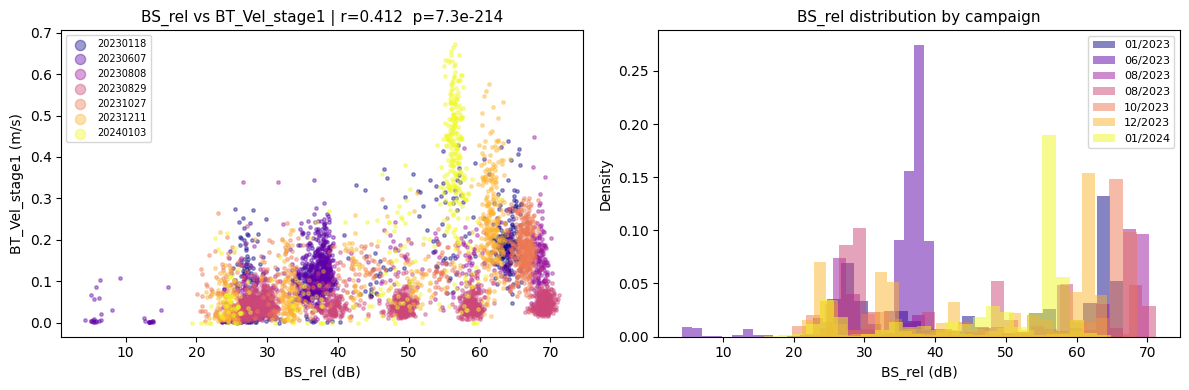


Physical correlation: r=0.412  p=7.3e-214  N=5247
Expected: positive r (~0.61) in field — higher hydraulic intensity → higher bed echo


In [24]:
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

if 'BS_rel' in df_final.columns:
    v = df_final[['BS_rel', 'BT_Vel_stage1']].dropna()
    r, p = scipy_stats.pearsonr(v['BS_rel'], v['BT_Vel_stage1'])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatter: BS_rel vs BT_Vel_stage1
    df_final['Campaign'] = df_final['Transect'].str.extract(r'_(\d{8})')
    camps = sorted(df_final['Campaign'].dropna().unique())
    cmap  = plt.cm.plasma(np.linspace(0, 1, len(camps)))
    for i, camp in enumerate(camps):
        sub = df_final[df_final['Campaign'] == camp][['BS_rel', 'BT_Vel_stage1']].dropna()
        axes[0].scatter(sub['BS_rel'], sub['BT_Vel_stage1'],
                        s=6, alpha=0.4, color=cmap[i], label=camp)
    axes[0].set_xlabel('BS_rel (dB)', fontsize=10)
    axes[0].set_ylabel('BT_Vel_stage1 (m/s)', fontsize=10)
    axes[0].set_title(f'BS_rel vs BT_Vel_stage1 | r={r:.3f}  p={p:.1e}', fontsize=11)
    axes[0].legend(fontsize=7, markerscale=3)

    # Histogram: BS_rel by campaign
    for i, camp in enumerate(camps):
        sub = df_final[df_final['Campaign'] == camp]['BS_rel'].dropna()
        axes[1].hist(sub, bins=25, alpha=0.5, color=cmap[i],
                     label=f'{camp[4:6]}/{camp[:4]}', density=True)
    axes[1].set_xlabel('BS_rel (dB)', fontsize=10)
    axes[1].set_ylabel('Density', fontsize=10)
    axes[1].set_title('BS_rel distribution by campaign', fontsize=11)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('field_bs_validation.png', dpi=150)
    plt.show()
    print(f'\nPhysical correlation: r={r:.3f}  p={p:.1e}  N={len(v)}')
    print('Expected: positive r (~0.61) in field — higher hydraulic intensity → higher bed echo')
else:
    print('BS_rel not available — check rsqmb extraction above')


In [1]:
import pandas as pd

# Base folder
base_path = (
    r"C:\Users\thtuh\Documents\Onedrive_personal\OneDrive"
    r"\Personal _Github\ADCP_ML_DL_Journal_1"
)

lab_path = base_path + r"\Processed_LAB_Data_with_BS.xlsx"
field_path = base_path + r"\Processed_Field_Data_with_BS.xlsx"

lab_df = pd.read_excel(lab_path)
field_df = pd.read_excel(field_path)

# Main features for manuscript statistics
stat_features = [
    "BT_Vel_stage1",
    "Depth",
    "Mean_Speed",
    "Vel_StdDev",
    "Correlation",
    "SNR",
    "Vel_Expected_StdDev",
    "Bin_Distance"
]

# Rename only for output/display
label_map = {
    "BT_Vel_stage1": "BT_Vel"
}

def make_stats(df, dataset_name):
    stats = df[stat_features].describe().T[["count", "mean", "std", "min", "max"]]
    stats = stats.rename(index=label_map)
    stats.insert(0, "Dataset", dataset_name)
    return stats

lab_stats = make_stats(lab_df, "Lab")
field_stats = make_stats(field_df, "Field")

combined_stats = pd.concat([lab_stats, field_stats])

# Round for manuscript checking
combined_stats_rounded = combined_stats.round({
    "count": 0,
    "mean": 5,
    "std": 5,
    "min": 5,
    "max": 5
})

print(combined_stats_rounded.to_string())

# Optional: save as Excel table
combined_stats_rounded.to_excel(
    base_path + r"\Lab_Field_Descriptive_Statistics_BT_Vel.xlsx"
)

                    Dataset    count      mean       std       min       max
BT_Vel                  Lab  11119.0   0.00770   0.02345   0.00000   0.22584
Depth                   Lab  24298.0   0.54745   0.03631   0.33773   0.90311
Mean_Speed              Lab  24298.0   0.16890   0.07014   0.03968   0.54373
Vel_StdDev              Lab  24298.0   0.00106   0.00198   0.00000   0.05543
Correlation             Lab  24298.0  44.50523   4.74664  25.56250  50.57143
SNR                     Lab  24298.0  44.59563   4.62273  15.39143  60.85625
Vel_Expected_StdDev     Lab  24298.0   0.00681   0.00219   0.00364   0.03304
Bin_Distance            Lab  24298.0   0.12884   0.01264   0.11699   0.19649
BT_Vel                Field   5297.0   0.10984   0.10695   0.00000   0.67220
Depth                 Field  10869.0   1.46331   0.39595   0.00000   3.03077
Mean_Speed            Field  10869.0   0.17488   0.20933   0.00000   1.21470
Vel_StdDev            Field  10772.0   0.00619   0.00931   0.00000   0.07430